In [1]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
RETURN_DATA_FILE_NAME =  "/content/drive/MyDrive/FT370/ProjectPart2/data/MonthlyReturn.csv"
LM_DATA_FILE_NAME =  "/content/drive/MyDrive/FT370/ProjectPart2/data/Loughran-McDonald_10X_Summaries_1993-2024.csv"
CIK_DATA_FILE_NAME =  "/content/drive/MyDrive/FT370/ProjectPart2/data/cik-cusip.csv"


In [3]:
import pandas as pd
import numpy as np

df_return = pd.read_csv(RETURN_DATA_FILE_NAME)
df_lm = pd.read_csv(LM_DATA_FILE_NAME)
df_cik = pd.read_csv(CIK_DATA_FILE_NAME)

print("Monthly return data set columns:")
print(df_return.columns)
print("Loughran-McDonald data set columns:")
print(df_lm.columns)
print("CIK data set columns:")
print(df_cik.columns)

print("\nMonthly return shape:")
print(df_return.shape)
print("Loughran-McDonald shape:")
print(df_lm.shape)
print("CIK shape:")
print(df_cik.shape)

print("\nMonthly return first 5 rows:")
print(df_return.head(5))
print("Loughran-McDonald first 5 rows:")
print(df_lm.head(5))
print("CIK first 5 rows:")
print(df_cik.head(5))

print("\nMonthly return RET data type:")
print(df_return["RET"].dtype)
print("Monthly return date data type:")
print(df_return["date"].dtype)
print("Loughran-McDonald CIK data type:")
print(df_lm["CIK"].dtype)
print("Louhgran-McDonald FILING-DATE data type:")
print(df_lm["FILING_DATE"].dtype)
print("CIK cik data type:")
print(df_cik["cik"].dtype)

print("\nMissing values, monthly return tickers:")
print(df_return["Ticker"].isna().sum())
print("Missing values, monthly return date:")
print(df_return["date"].isna().sum())
print("Missing values, monthly return ret:")
print(df_return["RET"].isna().sum())
print("Missing values, loughran-mcdonald cik:")
print(df_lm["CIK"].isna().sum())
print("Missing values, loughran-mcdonald filing date:")
print(df_lm["FILING_DATE"].isna().sum())
print("Missing values: Loughran-McDonald cik:")
print(df_lm["CIK"].isna().sum())

#Converting returns to numeric values
ret_numeric_check = pd.to_numeric(df_return["RET"], errors="coerce")
print("\nMissing values, monthly return ret before:")
print(df_return["RET"].isna().sum())
print("RET values missing after numeric conversion:")
print(ret_numeric_check.isna().sum())
non_numeric_ret = df_return.loc[ret_numeric_check.isna() & df_return["RET"].notna(), "RET"]
print("Number of non-missing RET values that cannot convert to numeric:")
print(non_numeric_ret.shape[0])

print("\nHow many forms are there?:")
print(df_lm["FORM_TYPE"].value_counts(dropna=False))

print("\nMonthly return date conversion check:")
date_check = pd.to_datetime(df_return["date"], errors="coerce")
print("Original missing monthly return dates:")
print(df_return["date"].isna().sum())
print("Monthly return dates missing after datetime conversion:")
print(date_check.isna().sum())

print("\nLoughran-McDonald FILING_DATE conversion check:")
filing_date_check = pd.to_datetime(df_lm["FILING_DATE"].astype(str), format="%Y%m%d", errors="coerce")
print("Original missing filing dates:")
print(df_lm["FILING_DATE"].isna().sum())
print("Filing dates missing after datetime conversion:")
print(filing_date_check.isna().sum())

print("\nMissing N_Words:")
print(df_lm["N_Words"].isna().sum())
print("Rows where N_Words is 0:")
print((df_lm["N_Words"] == 0).sum())
print("Rows where N_Uncertainty is 0:")
print((df_lm["N_Uncertainty"] == 0).sum())

print("\nLM category missing values:")
lm_category_columns = ["N_Positive","N_Negative","N_Uncertainty","N_Litigious","N_StrongModal","N_WeakModal","N_Constraining"]
print(df_lm[lm_category_columns].isna().sum())

print("\nDuplicate return rows check:")
duplicate_return_rows = df_return.duplicated(subset=["PERMNO", "date"]).sum()
print(duplicate_return_rows)

Monthly return data set columns:
Index(['PERMNO', 'date', 'Ticker', 'COMNAM', 'RET'], dtype='object')
Loughran-McDonald data set columns:
Index(['CIK', 'FILING_DATE', 'ACC_NUM', 'CPR', 'FORM_TYPE', 'CoName', 'SIC',
       'FFInd', 'N_Words', 'N_Unique_Words', 'N_Negative', 'N_Positive',
       'N_Uncertainty', 'N_Litigious', 'N_StrongModal', 'N_WeakModal',
       'N_Constraining', 'N_Complexity', 'N_Negation', 'GrossFileSize',
       'NetFileSize', 'NonTextDocTypeChars', 'HTMLChars', 'XBRLChars',
       'XMLChars', 'N_Exhibits'],
      dtype='object')
CIK data set columns:
Index(['validated', 'cik', 'coname', 'cusip_full', 'cusip', 'cikdate1',
       'cikdate2', 'tmatch', 'issuer', 'issue', 'issue_check'],
      dtype='object')

Monthly return shape:
(1048575, 5)
Loughran-McDonald shape:
(1224508, 26)
CIK shape:
(31800, 11)

Monthly return first 5 rows:
   PERMNO       date Ticker              COMNAM        RET
0   10001  1/29/1993   GFGC  GREAT FALLS GAS CO          0
1   10001  2/26/

In [4]:
df_return_clean = df_return.copy()

df_return_clean["Ticker"] = df_return_clean["Ticker"].str.strip().str.upper()
df_return_clean.loc[df_return["Ticker"].isna(), "Ticker"] = np.nan
print("TIckers that are missing after cleaning")
print(df_return_clean["Ticker"].isna().sum())

df_return_clean["RET"] = pd.to_numeric(df_return_clean["RET"], errors="coerce")
print("RETs that are missing after cleaning")
print(df_return_clean["RET"].isna().sum())

df_return_clean["date"] = pd.to_datetime(df_return_clean["date"], errors="coerce")
print("Dates that are missing after cleaning")
print(df_return_clean["date"].isna().sum())

df_return_clean = df_return_clean.dropna(subset=["Ticker", "RET", "date"]).copy()
print("Mising values after dropping unusable values:")
print(df_return_clean[["Ticker", "date", "RET"]].isna().sum())

df_return_clean["year"] = df_return_clean["date"].dt.year
df_return_clean["month"] = df_return_clean["date"].dt.month
print(df_return_clean.head(5))

print("Checking rows after cleaning:")
print(df_return_clean.shape)

TIckers that are missing after cleaning
20171
RETs that are missing after cleaning
37752
Dates that are missing after cleaning
0
Mising values after dropping unusable values:
Ticker    0
date      0
RET       0
dtype: int64
   PERMNO       date Ticker              COMNAM       RET  year  month
0   10001 1993-01-29   GFGC  GREAT FALLS GAS CO  0.000000  1993      1
1   10001 1993-02-26   GFGC  GREAT FALLS GAS CO  0.017857  1993      2
2   10001 1993-03-31   GFGC  GREAT FALLS GAS CO  0.011053  1993      3
3   10001 1993-04-30   GFGC  GREAT FALLS GAS CO  0.070175  1993      4
4   10001 1993-05-28   GFGC  GREAT FALLS GAS CO -0.008197  1993      5
Checking rows after cleaning:
(1010795, 7)


In [5]:
import requests
import json

#Download SEC ticker-to-CIK mapping
sec_url = "https://www.sec.gov/files/company_tickers.json"

headers = {"User-Agent": "Jeremy Faubert jfaubert@falcon.bentley.edu"}

response = requests.get(sec_url, headers=headers)

sec_data = response.json()

df_sec = pd.DataFrame.from_dict(sec_data, orient="index")
df_sec.columns = ["CIK", "Ticker", "CompanyName"]

df_sec["Ticker"] = df_sec["Ticker"].str.strip().str.upper()

df_sec["CIK"] = df_sec["CIK"].astype(str).str.zfill(10)

print("\nSEC ticker-to-CIK mapping loaded successfully.")
print("SEC mapping shape:")
print(df_sec.shape)

print("\nFirst 5 rows:")
print(df_sec.head(5))

print("\nMissing values:")
print(df_sec[["CIK", "Ticker", "CompanyName"]].isna().sum())

print("\nUnique tickers:")
print(df_sec["Ticker"].nunique())

print("\nUnique CIKs:")
print(df_sec["CIK"].nunique())


SEC ticker-to-CIK mapping loaded successfully.
SEC mapping shape:
(10341, 3)

First 5 rows:
          CIK Ticker     CompanyName
0  0001045810   NVDA     NVIDIA CORP
1  0001652044  GOOGL   Alphabet Inc.
2  0000320193   AAPL      Apple Inc.
3  0000789019   MSFT  MICROSOFT CORP
4  0001018724   AMZN  AMAZON COM INC

Missing values:
CIK            0
Ticker         0
CompanyName    0
dtype: int64

Unique tickers:
10341

Unique CIKs:
7993


In [6]:
df_return_cik = pd.merge(df_return_clean,df_sec[["Ticker", "CIK", "CompanyName"]],on="Ticker",how="inner")

print("Monthly return rows after SEC merge:")
print(df_return_cik.shape)
print("\nUnique tickers after SEC merge:")
print(df_return_cik["Ticker"].nunique())
print("\nUnique CIKs after SEC merge:")
print(df_return_cik["CIK"].nunique())

Monthly return rows after SEC merge:
(380630, 9)

Unique tickers after SEC merge:
3667

Unique CIKs after SEC merge:
3633


In [7]:
df_lm_clean = df_lm.copy()
df_lm_clean["FORM_TYPE"] = df_lm_clean["FORM_TYPE"].str.strip().str.upper()

main_form_types = ["10-K", "10-Q","10KSB","10QSB","10-K405", "10KSB40","10-KT","10-QT"]
robustness_check_form_types = ["10-K", "10-Q", "10KSB", "10QSB", "10-K405", "10KSB40", "10-KT", "10-QT", "10-K-A", "10-Q-A", "10-K405-A", "10QSB-A", "10KSB-A", "10KSB40-A", "10-KT-A", "10-QT-A"]

df_lm_main = df_lm_clean[df_lm_clean["FORM_TYPE"].isin(main_form_types)].copy()
df_lm_robustness = df_lm_clean[df_lm_clean["FORM_TYPE"].isin(robustness_check_form_types)].copy()

print("Main model shape:")
print(df_lm_main.shape)
print(df_lm_main["FORM_TYPE"].value_counts())

print("Robustness model check shape:")
print(df_lm_robustness.shape)
print(df_lm_robustness["FORM_TYPE"].value_counts())

Main model shape:
(1097518, 26)
FORM_TYPE
10-Q       688966
10-K       225970
10QSB      120120
10KSB       36912
10-K405     21276
10KSB40      3441
10-KT         587
10-QT         246
Name: count, dtype: int64
Robustness model check shape:
(1224397, 26)
FORM_TYPE
10-Q         688966
10-K         225970
10QSB        120120
10-Q-A        46895
10-K-A        46810
10KSB         36912
10-K405       21276
10QSB-A       17117
10KSB-A       11909
10KSB40        3441
10-K405-A      3349
10KSB40-A       625
10-KT           587
10-QT           246
10-KT-A         137
10-QT-A          37
Name: count, dtype: int64


In [8]:
df_lm_main["filing_date"] = pd.to_datetime(df_lm_main["FILING_DATE"].astype(str), format="%Y%m%d", errors="coerce")
df_lm_main["year"] = df_lm_main["filing_date"].dt.year
df_lm_main["month"] = df_lm_main["filing_date"].dt.month
print("Missing filing_date after conversion:")
print(df_lm_main["filing_date"].isna().sum())
print(df_lm_main.head(5))

Missing filing_date after conversion:
0
     CIK  FILING_DATE               ACC_NUM       CPR FORM_TYPE  \
0  60512     19930813  0000060512-94-000005  19930630      10-Q   
1  66740     19930813  0000066740-94-000015  19930630      10-Q   
3  60512     19931110  0000060512-94-000007  19930930      10-Q   
4  11860     19931112  0000011860-94-000005  19930930      10-Q   
5  20762     19931112  0000950131-94-000025  19930930      10-Q   

                                CoName   SIC  FFInd  N_Words  N_Unique_Words  \
0      LOUISIANA LAND & EXPLORATION CO  1311     30     4068             770   
1  MINNESOTA MINING & MANUFACTURING CO  2670     38     4389             844   
3      LOUISIANA LAND & EXPLORATION CO  1311     30     4938             812   
4            BETHLEHEM STEEL CORP /DE/  3312     19     3823             898   
5       CLARK REFINING & MARKETING INC  2911     30     4136             885   

   ...  GrossFileSize  NetFileSize  NonTextDocTypeChars  HTMLChars  XBRLChar

In [9]:
df_lm_main["Baseline_Sentiment"] = ((df_lm_main["N_Positive"] - df_lm_main["N_Negative"])/ df_lm_main["N_Uncertainty"]) + 1
df_lm_main["Baseline_Sentiment"] = df_lm_main["Baseline_Sentiment"].replace([np.inf, -np.inf], np.nan)
print("Baseline model sentiment missing values:")
print(df_lm_main["Baseline_Sentiment"].isna().sum())

Baseline model sentiment missing values:
2695


In [10]:
df_lm_signal = df_lm_main.copy()

df_lm_signal = df_lm_signal[df_lm_signal["N_Words"]> 0].copy()
print(df_lm_signal.shape)

df_lm_signal["positive_rate"] = df_lm_signal["N_Positive"] / df_lm_signal["N_Words"]
df_lm_signal["negative_rate"] = df_lm_signal["N_Negative"] / df_lm_signal["N_Words"]
df_lm_signal["uncertainty_rate"] = df_lm_signal["N_Uncertainty"] / df_lm_signal["N_Words"]
df_lm_signal["litigious_rate"] = df_lm_signal["N_Litigious"] / df_lm_signal["N_Words"]
df_lm_signal["strong_modal_rate"] = df_lm_signal["N_StrongModal"] / df_lm_signal["N_Words"]
df_lm_signal["weak_modal_rate"] = df_lm_signal["N_WeakModal"] / df_lm_signal["N_Words"]
df_lm_signal["constraining_rate"] = df_lm_signal["N_Constraining"] / df_lm_signal["N_Words"]

rate_columns = ["positive_rate", "negative_rate", "uncertainty_rate", "litigious_rate", "strong_modal_rate", "weak_modal_rate", "constraining_rate"]
print(df_lm_signal[rate_columns].isna().sum())

(1097455, 30)
positive_rate        0
negative_rate        0
uncertainty_rate     0
litigious_rate       0
strong_modal_rate    0
weak_modal_rate      0
constraining_rate    0
dtype: int64


In [11]:
df_lm_signal = df_lm_signal.sort_values(["CIK", "year", "month", "filing_date"]).copy()
df_lm_monthly = df_lm_signal.drop_duplicates(subset=["CIK", "year", "month"], keep="last").copy()

print(df_lm_monthly.shape)
print(df_lm_monthly[["CIK", "filing_date", "year", "month", "FORM_TYPE", "positive_rate", "negative_rate", "uncertainty_rate", "litigious_rate", "strong_modal_rate", "weak_modal_rate", "constraining_rate", "Baseline_Sentiment"]].head())

(1068843, 37)
       CIK filing_date  year  month FORM_TYPE  positive_rate  negative_rate  \
17429   20  1995-05-16  1995      5      10-Q       0.002857       0.020260   
23230   20  1995-08-15  1995      8      10-Q       0.003411       0.018759   
25932   20  1995-11-03  1995     11      10-Q       0.003717       0.017348   
35996   20  1996-03-28  1996      3      10-K       0.003318       0.015585   
39641   20  1996-05-02  1996      5      10-Q       0.004633       0.015222   

       uncertainty_rate  litigious_rate  strong_modal_rate  weak_modal_rate  \
17429          0.003723        0.061472           0.001039         0.002251   
23230          0.003752        0.006139           0.002387         0.001023   
25932          0.004027        0.005576           0.001859         0.001549   
35996          0.005440        0.038514           0.002366         0.003617   
39641          0.001985        0.005956           0.002978         0.000000   

       constraining_rate  Baseline_S

In [12]:
df_model = df_return_cik.copy()
df_model["CIK"] = df_model["CIK"].astype(int)
lm_columns_to_merge = ["CIK", "year", "month", "filing_date", "FORM_TYPE", "Baseline_Sentiment", "positive_rate", "negative_rate", "uncertainty_rate", "litigious_rate", "strong_modal_rate", "weak_modal_rate", "constraining_rate", "FFInd", "SIC"]
df_lm_to_merge = df_lm_monthly[lm_columns_to_merge].copy()

df_model = df_model.merge(df_lm_to_merge, on=["CIK", "year", "month"], how="left")
print(df_model.shape)

print(df_model["Baseline_Sentiment"].notna().sum())
rate_columns = ["positive_rate", "negative_rate", "uncertainty_rate", "litigious_rate", "strong_modal_rate", "weak_modal_rate", "constraining_rate"]
print(df_model[rate_columns].notna().sum())
print(df_model[["PERMNO", "date", "Ticker", "COMNAM", "RET", "CIK", "year", "month", "filing_date", "FORM_TYPE", "Baseline_Sentiment"]].head())

(380630, 21)
91940
positive_rate        91969
negative_rate        91969
uncertainty_rate     91969
litigious_rate       91969
strong_modal_rate    91969
weak_modal_rate      91969
constraining_rate    91969
dtype: int64
   PERMNO       date Ticker                  COMNAM       RET     CIK  year  \
0   10026 1993-01-29   JJSF  J & J SNACK FOODS CORP  0.027778  785956  1993   
1   10026 1993-02-26   JJSF  J & J SNACK FOODS CORP  0.067568  785956  1993   
2   10026 1993-03-31   JJSF  J & J SNACK FOODS CORP  0.177215  785956  1993   
3   10026 1993-04-30   JJSF  J & J SNACK FOODS CORP  0.193548  785956  1993   
4   10026 1993-05-28   JJSF  J & J SNACK FOODS CORP  0.063063  785956  1993   

   month filing_date FORM_TYPE  Baseline_Sentiment  
0      1         NaT       NaN                 NaN  
1      2         NaT       NaN                 NaN  
2      3         NaT       NaN                 NaN  
3      4         NaT       NaN                 NaN  
4      5         NaT       NaN         

In [13]:
df_model["month_index"] = (df_model["year"] - df_model["year"].min()) * 12 + df_model["month"]
df_model = df_model.sort_values(["PERMNO", "month_index"]).copy()
columns_to_fill = ["filing_date", "FORM_TYPE", "Baseline_Sentiment", "positive_rate", "negative_rate", "uncertainty_rate", "litigious_rate", "strong_modal_rate", "weak_modal_rate", "constraining_rate", "FFInd", "SIC"]

print(df_model["Baseline_Sentiment"].notna().sum())
print(df_model[rate_columns].notna().sum())

for col in columns_to_fill:
    df_model[col] = df_model.groupby("PERMNO")[col].ffill(limit=3)

print(df_model["Baseline_Sentiment"].notna().sum())
print(df_model[rate_columns].notna().sum())

print(df_model[["PERMNO", "date", "Ticker", "RET", "CIK", "year", "month", "filing_date", "FORM_TYPE", "Baseline_Sentiment", "positive_rate", "negative_rate", "uncertainty_rate"]].head())

91940
positive_rate        91969
negative_rate        91969
uncertainty_rate     91969
litigious_rate       91969
strong_modal_rate    91969
weak_modal_rate      91969
constraining_rate    91969
dtype: int64
270750
positive_rate        270814
negative_rate        270814
uncertainty_rate     270814
litigious_rate       270814
strong_modal_rate    270814
weak_modal_rate      270814
constraining_rate    270814
dtype: int64
   PERMNO       date Ticker       RET     CIK  year  month filing_date  \
0   10026 1993-01-29   JJSF  0.027778  785956  1993      1         NaT   
1   10026 1993-02-26   JJSF  0.067568  785956  1993      2         NaT   
2   10026 1993-03-31   JJSF  0.177215  785956  1993      3         NaT   
3   10026 1993-04-30   JJSF  0.193548  785956  1993      4         NaT   
4   10026 1993-05-28   JJSF  0.063063  785956  1993      5         NaT   

  FORM_TYPE  Baseline_Sentiment  positive_rate  negative_rate  \
0       NaN                 NaN            NaN            NaN   
1

In [14]:
df_model = df_model.sort_values(["PERMNO", "month_index"]).copy()

df_model["Next_Month_Return"] = df_model.groupby("PERMNO")["RET"].shift(-1)

print(df_model["RET"].notna().sum())
print(df_model["Next_Month_Return"].notna().sum())
print(df_model["Next_Month_Return"].isna().sum())

380630
376653
3977


In [15]:
def monthly_z_score(series):
    mean_value = series.mean()
    std_value = series.std()

    if pd.isna(std_value) or std_value == 0:
        return series * np.nan

    return (series - mean_value) / std_value

z_rate_columns = []

for col in rate_columns:
    z_col = "z_" + col

    df_model[z_col] = df_model.groupby(["year", "month"])[col].transform(monthly_z_score)

    z_rate_columns.append(z_col)

df_model["Expanded_LM_Signal"] = (df_model["z_positive_rate"] - df_model["z_negative_rate"] - df_model["z_uncertainty_rate"] - df_model["z_litigious_rate"] - df_model["z_constraining_rate"] + df_model["z_strong_modal_rate"] - df_model["z_weak_modal_rate"])

print(z_rate_columns)

print(df_model["Expanded_LM_Signal"].notna().sum())

print(df_model[["PERMNO", "date", "Ticker", "RET", "Next_Month_Return", "Expanded_LM_Signal", "z_positive_rate", "z_negative_rate", "z_uncertainty_rate", "z_litigious_rate", "z_constraining_rate", "z_strong_modal_rate", "z_weak_modal_rate"]].sample())

['z_positive_rate', 'z_negative_rate', 'z_uncertainty_rate', 'z_litigious_rate', 'z_strong_modal_rate', 'z_weak_modal_rate', 'z_constraining_rate']
270809
        PERMNO       date Ticker      RET  Next_Month_Return  \
305403   33099 2006-05-31    IMO  0.00046           0.009379   

        Expanded_LM_Signal  z_positive_rate  z_negative_rate  \
305403            4.133404        -0.280016        -1.206648   

        z_uncertainty_rate  z_litigious_rate  z_constraining_rate  \
305403           -1.849539         -1.058609            -1.053333   

        z_strong_modal_rate  z_weak_modal_rate  
305403            -1.355791          -0.601081  


In [16]:
backtest_columns = ["PERMNO", "date", "Ticker", "COMNAM", "CIK", "year", "month", "month_index", "RET", "Next_Month_Return", "Baseline_Sentiment", "Expanded_LM_Signal", "FFInd", "SIC"]
df_backtest = df_model[backtest_columns].copy()

print(df_backtest.shape)

print(df_backtest[["PERMNO", "date", "Ticker", "CIK", "Next_Month_Return", "Baseline_Sentiment", "Expanded_LM_Signal", "FFInd"]].isna().sum())
print(df_backtest.head())

(380630, 14)
PERMNO                     0
date                       0
Ticker                     0
CIK                        0
Next_Month_Return       3977
Baseline_Sentiment    109880
Expanded_LM_Signal    109821
FFInd                 109816
dtype: int64
   PERMNO       date Ticker                  COMNAM     CIK  year  month  \
0   10026 1993-01-29   JJSF  J & J SNACK FOODS CORP  785956  1993      1   
1   10026 1993-02-26   JJSF  J & J SNACK FOODS CORP  785956  1993      2   
2   10026 1993-03-31   JJSF  J & J SNACK FOODS CORP  785956  1993      3   
3   10026 1993-04-30   JJSF  J & J SNACK FOODS CORP  785956  1993      4   
4   10026 1993-05-28   JJSF  J & J SNACK FOODS CORP  785956  1993      5   

   month_index       RET  Next_Month_Return  Baseline_Sentiment  \
0            1  0.027778           0.067568                 NaN   
1            2  0.067568           0.177215                 NaN   
2            3  0.177215           0.193548                 NaN   
3            4  0

In [17]:
baseline_results = []

for year in range(1994, 2024):
  for month in range(1,13):
    month_data = df_backtest[(df_backtest["year"] == year) & (df_backtest["month"] == month)].copy()
    month_data = month_data[["PERMNO", "Ticker", "Baseline_Sentiment", "Next_Month_Return"]].dropna()

    if len(month_data) == 0:
      continue
    benchmark_return = month_data["Next_Month_Return"].mean()
    long_data = month_data[month_data["Baseline_Sentiment"] > 0].copy()

    if len(long_data) > 0:
      long_data["weight"] = (long_data["Baseline_Sentiment"]/long_data["Baseline_Sentiment"].abs().sum())
      long_return = (long_data["weight"] * long_data["Next_Month_Return"]).sum()
    else:
      long_return = np.nan

    short_data = month_data[month_data["Baseline_Sentiment"] < 0].copy()

    if len(short_data) > 0:
      short_data["weight"] = (short_data["Baseline_Sentiment"]/short_data["Baseline_Sentiment"].abs().sum())
      short_return = (short_data["weight"] * short_data["Next_Month_Return"]).sum()
    else:
      short_return = np.nan

    if pd.notna(long_return) and pd.notna(short_return):
      long_short_return = long_return - short_return
    else:
      long_short_return = np.nan

    baseline_results.append({"year": year, "month": month, "benchmark_return": benchmark_return, "long_return": long_return, "short_return": short_return, "long_short_return": long_short_return, "num_firms": len(month_data), "num_long": len(long_data), "num_short": len(short_data)})

baseline_results = pd.DataFrame(baseline_results)

print(baseline_results.shape)
print(baseline_results.head())

print("Missing baseline long-short returns:")
print(baseline_results["long_short_return"].isna().sum())

print("\nBaseline results summary:")
print(baseline_results[["benchmark_return", "long_return", "short_return", "long_short_return", "num_firms", "num_long", "num_short"]].describe())

(360, 9)
   year  month  benchmark_return  long_return  short_return  \
0  1994      1          0.013192    -0.007918     -0.052309   
1  1994      2         -0.047815    -0.050413      0.007640   
2  1994      3          0.006567    -0.005220     -0.012147   
3  1994      4          0.008108     0.006554      0.003207   
4  1994      5         -0.011891    -0.011716      0.011316   

   long_short_return  num_firms  num_long  num_short  
0           0.044391         16        11          5  
1          -0.058053         50        30         19  
2           0.006927        161        92         67  
3           0.003347        170        94         74  
4          -0.023032        182        95         79  
Missing baseline long-short returns:
0

Baseline results summary:
       benchmark_return  long_return  short_return  long_short_return  \
count        360.000000   360.000000    360.000000         360.000000   
mean           0.011819     0.010524     -0.012612           0.023136 

In [18]:
main_results = []

for year in range(1994, 2024):
  for month in range(1, 13):

    month_data = df_backtest[(df_backtest["year"] == year) & (df_backtest["month"] == month)].copy()

    month_data = month_data[["PERMNO", "Ticker", "Expanded_LM_Signal", "Next_Month_Return"]].dropna()

    if len(month_data) < 5:
      continue

    benchmark_return = month_data["Next_Month_Return"].mean()

    month_data["signal_rank"] = month_data["Expanded_LM_Signal"].rank(method="first")

    month_data["quintile"] = pd.qcut(month_data["signal_rank"],q=5, labels=["F1", "F2", "F3", "F4", "F5"])

    quintile_returns = month_data.groupby("quintile", observed=False)["Next_Month_Return"].mean()

    f1_return = quintile_returns.loc["F1"]
    f2_return = quintile_returns.loc["F2"]
    f3_return = quintile_returns.loc["F3"]
    f4_return = quintile_returns.loc["F4"]
    f5_return = quintile_returns.loc["F5"]

    long_short_return = f5_return - f1_return

    main_results.append({"year": year, "month": month, "benchmark_return": benchmark_return, "F1_return": f1_return, "F2_return": f2_return, "F3_return": f3_return, "F4_return": f4_return, "F5_return": f5_return, "long_short_return": long_short_return, "F5_minus_benchmark": f5_return - benchmark_return, "benchmark_minus_F1": benchmark_return - f1_return, "num_firms": len(month_data), "F1_count": (month_data["quintile"] == "F1").sum(), "F2_count": (month_data["quintile"] == "F2").sum(), "F3_count": (month_data["quintile"] == "F3").sum(), "F4_count": (month_data["quintile"] == "F4").sum(), "F5_count": (month_data["quintile"] == "F5").sum()})

main_results = pd.DataFrame(main_results)

print("Main expanded LM backtest shape:")
print(main_results.shape)

print("\nFirst 5 rows:")
print(main_results.head())

print("\nMissing long-short returns:")
print(main_results["long_short_return"].isna().sum())

print("\nMain expanded LM summary:")
print(main_results[["benchmark_return", "F1_return", "F2_return", "F3_return", "F4_return", "F5_return", "long_short_return", "F5_minus_benchmark", "benchmark_minus_F1", "num_firms"]].describe())

Main expanded LM backtest shape:
(360, 17)

First 5 rows:
   year  month  benchmark_return  F1_return  F2_return  F3_return  F4_return  \
0  1994      1          0.013192   0.032718  -0.004865   0.010298   0.036433   
1  1994      2         -0.047815  -0.064801  -0.032721  -0.050704  -0.038333   
2  1994      3          0.006963   0.020653   0.002159   0.012866  -0.004196   
3  1994      4          0.008108   0.001081   0.049497   0.000637  -0.015997   
4  1994      5         -0.011891  -0.025511  -0.012901  -0.001313  -0.016998   

   F5_return  long_short_return  F5_minus_benchmark  benchmark_minus_F1  \
0  -0.015130          -0.047847           -0.028322           -0.019525   
1  -0.052517           0.012284           -0.004702            0.016986   
2   0.003025          -0.017628           -0.003937           -0.013691   
3   0.005322           0.004241           -0.002786            0.007027   
4  -0.002612           0.022899            0.009279            0.013620   

   num_fir

In [19]:
df_enhanced = df_backtest.copy()

def cap_extreme_monthly_returns(series):
  lower_bound = series.quantile(0.01)
  upper_bound = series.quantile(0.99)

  return series.clip(lower=lower_bound, upper=upper_bound)

df_enhanced["Next_Month_Return_Capped"] = (df_enhanced.groupby(["year", "month"])["Next_Month_Return"].transform(cap_extreme_monthly_returns))

print("Original next-month return summary:")
print(df_enhanced["Next_Month_Return"].describe())

print("\nCapped next-month return summary:")
print(df_enhanced["Next_Month_Return_Capped"].describe())

print("\nMissing capped next-month returns:")
print(df_enhanced["Next_Month_Return_Capped"].isna().sum())

Original next-month return summary:
count    376653.000000
mean          0.009961
std           0.214589
min          -0.966196
25%          -0.062300
50%           0.002914
75%           0.065476
max          39.000000
Name: Next_Month_Return, dtype: float64

Capped next-month return summary:
count    376653.000000
mean          0.006673
std           0.148069
min          -0.723645
25%          -0.062300
50%           0.002914
75%           0.065476
max           1.398733
Name: Next_Month_Return_Capped, dtype: float64

Missing capped next-month returns:
3977


In [20]:
def apply_weight_cap(raw_weights, cap=0.05):
  raw_weights = raw_weights.copy()
  raw_weights = raw_weights.replace([np.inf, -np.inf], np.nan).dropna()
  raw_weights = raw_weights[raw_weights > 0]

  if len(raw_weights) == 0:
    return raw_weights

  weights = raw_weights / raw_weights.sum()

  if len(weights) * cap < 1:
    return weights

  capped_weights = weights.copy()

  for i in range(100):
    over_cap = capped_weights > cap

    if over_cap.sum() == 0:
      break

    excess_weight = (capped_weights[over_cap] - cap).sum()
    capped_weights[over_cap] = cap

    under_cap = capped_weights < cap

    if under_cap.sum() == 0:
      break

    redistribution_weights = capped_weights[under_cap] / capped_weights[under_cap].sum()
    capped_weights[under_cap] = capped_weights[under_cap] + redistribution_weights * excess_weight

  capped_weights = capped_weights / capped_weights.sum()

  return capped_weights

enhanced_results = []

for year in range(1994, 2024):
  for month in range(1, 13):

    month_data = df_enhanced[(df_enhanced["year"] == year) & (df_enhanced["month"] == month)].copy()

    month_data = month_data[["PERMNO", "Ticker", "FFInd", "Expanded_LM_Signal", "Next_Month_Return_Capped"]].dropna()

    if len(month_data) < 5:
      continue

    benchmark_return = month_data["Next_Month_Return_Capped"].mean()

    ranked_groups = []

    for industry, industry_data in month_data.groupby("FFInd"):
      industry_data = industry_data.copy()

      if len(industry_data) < 5:
        continue

      industry_data["signal_rank"] = industry_data["Expanded_LM_Signal"].rank(method="first")

      industry_data["quintile"] = pd.qcut(industry_data["signal_rank"], q=5, labels=["F1", "F2", "F3", "F4", "F5"])

      ranked_groups.append(industry_data)

    if len(ranked_groups) == 0:
      continue

    ranked_month_data = pd.concat(ranked_groups, ignore_index=True)

    quintile_returns = ranked_month_data.groupby("quintile", observed=False)["Next_Month_Return_Capped"].mean()

    f1_return = quintile_returns.loc["F1"]
    f2_return = quintile_returns.loc["F2"]
    f3_return = quintile_returns.loc["F3"]
    f4_return = quintile_returns.loc["F4"]
    f5_return = quintile_returns.loc["F5"]

    long_data = ranked_month_data[ranked_month_data["quintile"] == "F5"].copy()
    short_data = ranked_month_data[ranked_month_data["quintile"] == "F1"].copy()

    long_raw_weights = (long_data["Expanded_LM_Signal"] - long_data["Expanded_LM_Signal"].min()) + 0.000000000001

    short_raw_weights = (short_data["Expanded_LM_Signal"].max() - short_data["Expanded_LM_Signal"]) + 0.000000000001

    long_weights = apply_weight_cap(long_raw_weights, cap=0.05)
    short_weights = apply_weight_cap(short_raw_weights, cap=0.05)

    weighted_long_return = (long_weights * long_data.loc[long_weights.index, "Next_Month_Return_Capped"]).sum()

    weighted_short_return = (short_weights * short_data.loc[short_weights.index, "Next_Month_Return_Capped"]).sum()

    long_short_return = weighted_long_return - weighted_short_return

    enhanced_results.append({"year": year, "month": month, "benchmark_return": benchmark_return, "F1_return": f1_return, "F2_return": f2_return, "F3_return": f3_return, "F4_return": f4_return, "F5_return": f5_return, "weighted_F1_return": weighted_short_return, "weighted_F5_return": weighted_long_return, "long_short_return": long_short_return, "F5_minus_benchmark": f5_return - benchmark_return, "benchmark_minus_F1": benchmark_return - f1_return, "num_firms_before_sector_filter": len(month_data), "num_firms_after_sector_filter": len(ranked_month_data), "num_industries": ranked_month_data["FFInd"].nunique(), "F1_count": len(short_data), "F5_count": len(long_data), "long_cap_possible": len(long_data) * 0.05 >= 1, "short_cap_possible": len(short_data) * 0.05 >= 1})

enhanced_results = pd.DataFrame(enhanced_results)

print("Enhanced strategy results shape:")
print(enhanced_results.shape)

print("\nFirst 5 enhanced strategy rows:")
print(enhanced_results.head())

print("\nMissing enhanced long-short returns:")
print(enhanced_results["long_short_return"].isna().sum())

print("\nEnhanced strategy summary:")
print(enhanced_results[["benchmark_return", "F1_return", "F2_return", "F3_return", "F4_return", "F5_return", "weighted_F1_return", "weighted_F5_return", "long_short_return", "num_firms_before_sector_filter", "num_firms_after_sector_filter", "num_industries", "F1_count", "F5_count"]].describe())

Enhanced strategy results shape:
(359, 20)

First 5 enhanced strategy rows:
   year  month  benchmark_return  F1_return  F2_return  F3_return  F4_return  \
0  1994      2         -0.047815  -0.009730  -0.093080  -0.008848  -0.059229   
1  1994      3          0.006984   0.018443   0.015457   0.022797   0.025144   
2  1994      4          0.001677  -0.009632  -0.004755   0.019491  -0.002356   
3  1994      5         -0.012026  -0.024014   0.006514  -0.011033  -0.010273   
4  1994      6          0.029816   0.025439   0.046984   0.039129   0.035830   

      F5_return  weighted_F1_return  weighted_F5_return  long_short_return  \
0 -7.295350e-02           -0.038462           -0.017467           0.020995   
1  1.328938e-02            0.026492            0.010308          -0.016184   
2  6.400000e-07           -0.010258           -0.003618           0.006640   
3 -1.072134e-02           -0.030025           -0.010280           0.019745   
4  2.604418e-02            0.020733            0.0274

In [21]:
def calculate_strategy_metrics(strategy_name, results_df, signal_data, signal_column, return_column):
  metrics = {}

  strategy_returns = pd.to_numeric(results_df["long_short_return"], errors="coerce").dropna()

  metrics["Average Monthly Long-Short Return"] = strategy_returns.mean()

  metrics["Information Ratio"] = strategy_returns.mean() / strategy_returns.std()

  metrics["Hit Rate"] = (strategy_returns > 0).mean()

  total_months = len(strategy_returns)
  cumulative_wealth = (1 + strategy_returns).prod()
  metrics["Annualized Return"] = cumulative_wealth ** (12 / total_months) - 1

  wealth_index = (1 + strategy_returns).cumprod()
  running_max = wealth_index.cummax()
  drawdown = wealth_index / running_max - 1
  metrics["Maximum Drawdown"] = drawdown.min()

  metrics["Sharpe Ratio"] = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(12)

  metrics["Cumulative Return"] = cumulative_wealth - 1

  backtest_months = results_df[["year", "month"]].drop_duplicates().copy()

  ic_values = []

  ic_data = signal_data[["year", "month", signal_column, return_column]].dropna().copy()
  ic_data = ic_data.merge(backtest_months, on=["year", "month"], how="inner")

  for (year, month), month_data in ic_data.groupby(["year", "month"]):
    if month_data[signal_column].nunique() > 1 and month_data[return_column].nunique() > 1:
      ic = month_data[signal_column].corr(month_data[return_column])
      ic_values.append(ic)

  metrics["Average IC"] = np.mean(ic_values)

  metrics["IC Months"] = len(ic_values)

  metrics_df = pd.DataFrame({"Strategy": strategy_name, "Metric": list(metrics.keys()), "Value": list(metrics.values())})

  return metrics_df

In [22]:
baseline_metrics = calculate_strategy_metrics(strategy_name="Baseline", results_df=baseline_results, signal_data=df_backtest, signal_column="Baseline_Sentiment", return_column="Next_Month_Return")

main_metrics = calculate_strategy_metrics(strategy_name="Expanded LM Quintiles", results_df=main_results, signal_data=df_backtest, signal_column="Expanded_LM_Signal", return_column="Next_Month_Return")

enhanced_metrics = calculate_strategy_metrics(strategy_name="Enhanced Sector-Neutral Capped", results_df=enhanced_results, signal_data=df_enhanced, signal_column="Expanded_LM_Signal", return_column="Next_Month_Return_Capped")

all_metrics = pd.concat([baseline_metrics, main_metrics, enhanced_metrics], ignore_index=True)

print("All strategy performance metrics:")
print(all_metrics)

All strategy performance metrics:
                          Strategy                             Metric  \
0               Baseline  Average Monthly Long-Short Return   
1               Baseline                  Information Ratio   
2               Baseline                           Hit Rate   
3               Baseline                  Annualized Return   
4               Baseline                   Maximum Drawdown   
5               Baseline                       Sharpe Ratio   
6               Baseline                  Cumulative Return   
7               Baseline                         Average IC   
8               Baseline                          IC Months   
9            Expanded LM Quintiles  Average Monthly Long-Short Return   
10           Expanded LM Quintiles                  Information Ratio   
11           Expanded LM Quintiles                           Hit Rate   
12           Expanded LM Quintiles                  Annualized Return   
13           Expanded LM Quintiles

In [23]:
all_metrics_clean = all_metrics.copy()

percent_metrics = ["Average Monthly Long-Short Return", "Hit Rate", "Annualized Return", "Maximum Drawdown", "Cumulative Return"]

all_metrics_clean["Formatted Value"] = all_metrics_clean.apply(lambda row: f"{row['Value']:.2%}" if row["Metric"] in percent_metrics else f"{row['Value']:.4f}", axis=1)

print(all_metrics_clean[["Strategy", "Metric", "Formatted Value"]])

                          Strategy                             Metric  \
0               Baseline  Average Monthly Long-Short Return   
1               Baseline                  Information Ratio   
2               Baseline                           Hit Rate   
3               Baseline                  Annualized Return   
4               Baseline                   Maximum Drawdown   
5               Baseline                       Sharpe Ratio   
6               Baseline                  Cumulative Return   
7               Baseline                         Average IC   
8               Baseline                          IC Months   
9            Expanded LM Quintiles  Average Monthly Long-Short Return   
10           Expanded LM Quintiles                  Information Ratio   
11           Expanded LM Quintiles                           Hit Rate   
12           Expanded LM Quintiles                  Annualized Return   
13           Expanded LM Quintiles                   Maximum Drawdow

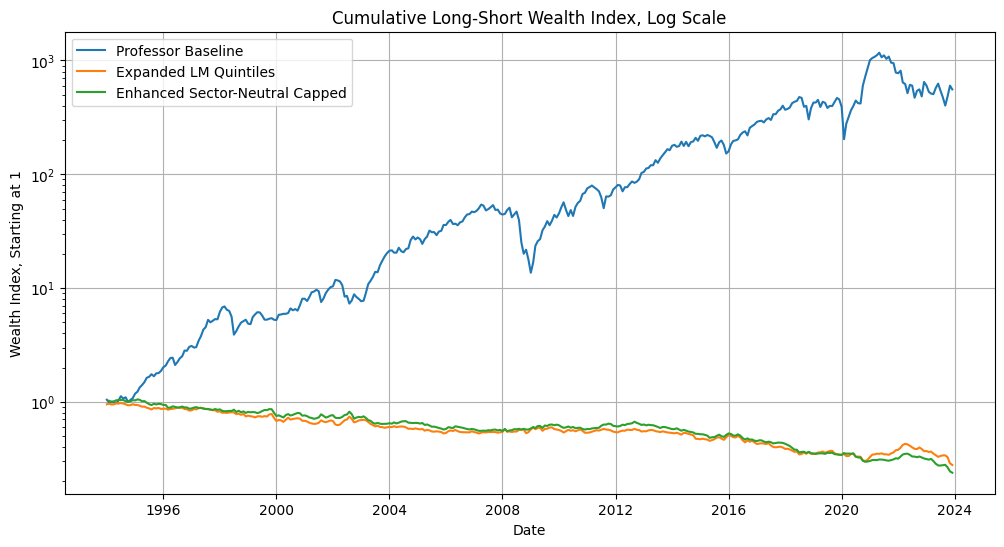

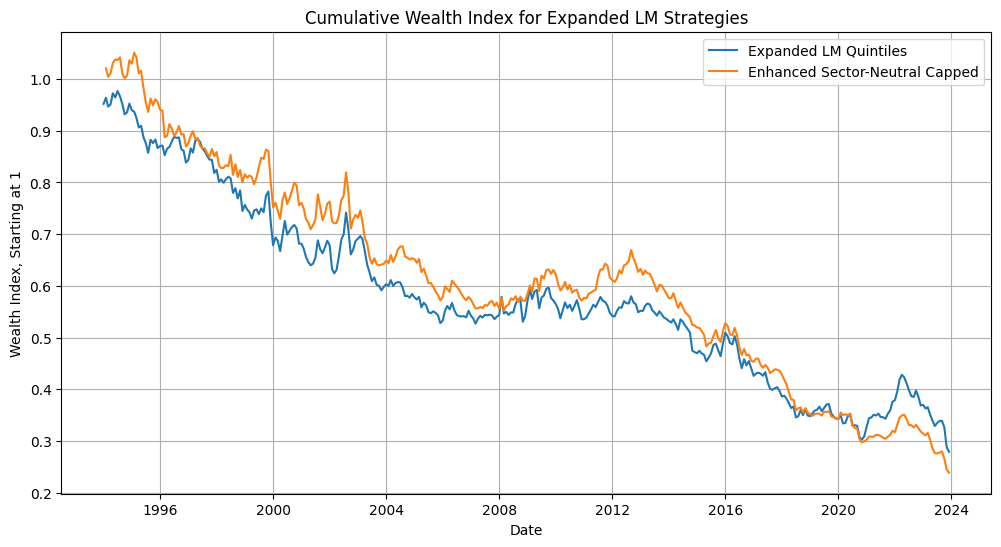

In [24]:
import matplotlib.pyplot as plt
baseline_plot = baseline_results.copy()
main_plot = main_results.copy()
enhanced_plot = enhanced_results.copy()

baseline_plot["date"] = pd.to_datetime(baseline_plot[["year", "month"]].assign(day=1))
main_plot["date"] = pd.to_datetime(main_plot[["year", "month"]].assign(day=1))
enhanced_plot["date"] = pd.to_datetime(enhanced_plot[["year", "month"]].assign(day=1))

baseline_plot["wealth_index"] = (1 + baseline_plot["long_short_return"]).cumprod()
main_plot["wealth_index"] = (1 + main_plot["long_short_return"]).cumprod()
enhanced_plot["wealth_index"] = (1 + enhanced_plot["long_short_return"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(baseline_plot["date"], baseline_plot["wealth_index"], label="Baseline")
plt.plot(main_plot["date"], main_plot["wealth_index"], label="Expanded LM Quintiles")
plt.plot(enhanced_plot["date"], enhanced_plot["wealth_index"], label="Enhanced Sector-Neutral Capped")
plt.yscale("log")
plt.title("Cumulative Long-Short Wealth Index, Log Scale")
plt.xlabel("Date")
plt.ylabel("Wealth Index, Starting at 1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(main_plot["date"], main_plot["wealth_index"], label="Expanded LM Quintiles")
plt.plot(enhanced_plot["date"], enhanced_plot["wealth_index"], label="Enhanced Sector-Neutral Capped")
plt.title("Cumulative Wealth Index for Expanded LM Strategies")
plt.xlabel("Date")
plt.ylabel("Wealth Index, Starting at 1")
plt.legend()
plt.grid(True)
plt.show()

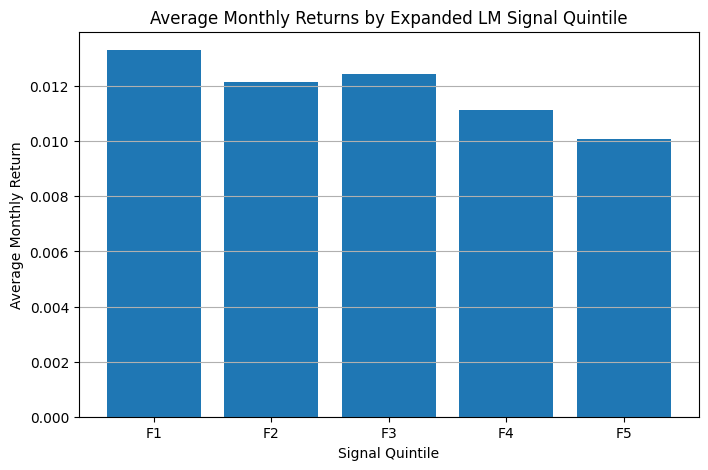

In [25]:
main_fractile_means = main_results[["F1_return", "F2_return", "F3_return", "F4_return", "F5_return"]].mean()

plt.figure(figsize=(8, 5))
plt.bar(["F1", "F2", "F3", "F4", "F5"], main_fractile_means.values)
plt.title("Average Monthly Returns by Expanded LM Signal Quintile")
plt.xlabel("Signal Quintile")
plt.ylabel("Average Monthly Return")
plt.grid(axis="y")
plt.show()

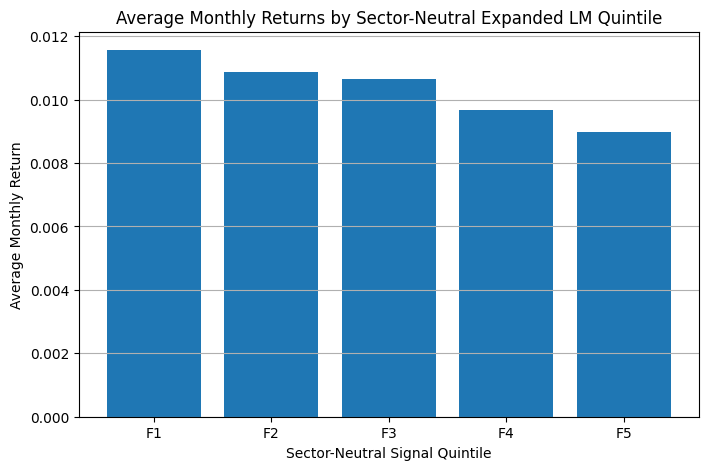

In [26]:
enhanced_fractile_means = enhanced_results[["F1_return", "F2_return", "F3_return", "F4_return", "F5_return"]].mean()

plt.figure(figsize=(8, 5))
plt.bar(["F1", "F2", "F3", "F4", "F5"], enhanced_fractile_means.values)
plt.title("Average Monthly Returns by Sector-Neutral Expanded LM Quintile")
plt.xlabel("Sector-Neutral Signal Quintile")
plt.ylabel("Average Monthly Return")
plt.grid(axis="y")
plt.show()

In [27]:
import statsmodels.formula.api as smf

df_regression = df_backtest.copy()

df_regression = df_regression[(df_regression["year"] >= 1994) & (df_regression["year"] <= 2023)].copy()

df_regression["year_month"] = df_regression["year"].astype(str) + "-" + df_regression["month"].astype(str).str.zfill(2)

baseline_regression_data = df_regression[["Next_Month_Return", "Baseline_Sentiment", "year_month"]].dropna().copy()
expanded_regression_data = df_regression[["Next_Month_Return", "Expanded_LM_Signal", "year_month"]].dropna().copy()

baseline_regression = smf.ols("Next_Month_Return ~ Baseline_Sentiment + C(year_month)", data=baseline_regression_data).fit()
expanded_regression = smf.ols("Next_Month_Return ~ Expanded_LM_Signal + C(year_month)", data=expanded_regression_data).fit()

regression_summary = pd.DataFrame({
    "Model": ["Baseline", "Expanded LM Signal"],
    "Signal Coefficient": [baseline_regression.params["Baseline_Sentiment"], expanded_regression.params["Expanded_LM_Signal"]],
    "t-stat": [baseline_regression.tvalues["Baseline_Sentiment"], expanded_regression.tvalues["Expanded_LM_Signal"]],
    "p-value": [baseline_regression.pvalues["Baseline_Sentiment"], expanded_regression.pvalues["Expanded_LM_Signal"]],
    "Adjusted R-squared": [baseline_regression.rsquared_adj, expanded_regression.rsquared_adj],
    "Observations": [baseline_regression.nobs, expanded_regression.nobs]
})

print(regression_summary)

                Model  Signal Coefficient    t-stat   p-value  \
0  Baseline           -0.001409 -2.579053  0.009908   
1  Expanded LM Signal           -0.000519 -4.633912  0.000004   

   Adjusted R-squared  Observations  
0            0.109805      242599.0  
1            0.109859      242663.0  


In [28]:
metrics_table = all_metrics.pivot(index="Strategy", columns="Metric", values="Value").reset_index()

metrics_table = metrics_table[["Strategy", "Average Monthly Long-Short Return", "Information Ratio", "Hit Rate", "Annualized Return", "Maximum Drawdown", "Sharpe Ratio", "Cumulative Return", "Average IC", "IC Months"]]

metrics_table_formatted = metrics_table.copy()

percent_columns = ["Average Monthly Long-Short Return", "Hit Rate", "Annualized Return", "Maximum Drawdown", "Cumulative Return"]

for col in percent_columns:
  metrics_table_formatted[col] = metrics_table_formatted[col].map(lambda x: f"{x:.2%}")

decimal_columns = ["Information Ratio", "Sharpe Ratio", "Average IC"]

for col in decimal_columns:
  metrics_table_formatted[col] = metrics_table_formatted[col].map(lambda x: f"{x:.4f}")

metrics_table_formatted["IC Months"] = metrics_table_formatted["IC Months"].astype(int)

print(metrics_table_formatted)

Metric                        Strategy Average Monthly Long-Short Return  \
0       Enhanced Sector-Neutral Capped                            -0.37%   
1                Expanded LM Quintiles                            -0.32%   
2                   Baseline                             2.31%   

Metric Information Ratio Hit Rate Annualized Return Maximum Drawdown  \
0                -0.1676   42.90%            -4.68%          -77.32%   
1                -0.1288   44.72%            -4.17%          -71.46%   
2                 0.2254   65.56%            23.46%          -74.81%   

Metric Sharpe Ratio Cumulative Return Average IC  IC Months  
0           -0.5805           -76.16%    -0.0090        359  
1           -0.4462           -72.12%    -0.0081        360  
2            0.7807         55628.22%    -0.0058        360  


In [29]:
fractile_table = pd.DataFrame({"Strategy": ["Expanded LM Quintiles", "Enhanced Sector-Neutral Capped"], "F1": [main_results["F1_return"].mean(), enhanced_results["F1_return"].mean()], "F2": [main_results["F2_return"].mean(), enhanced_results["F2_return"].mean()], "F3": [main_results["F3_return"].mean(), enhanced_results["F3_return"].mean()], "F4": [main_results["F4_return"].mean(), enhanced_results["F4_return"].mean()], "F5": [main_results["F5_return"].mean(), enhanced_results["F5_return"].mean()], "F5 - F1": [main_results["long_short_return"].mean(), enhanced_results["long_short_return"].mean()], "F5 - Benchmark": [main_results["F5_minus_benchmark"].mean(), enhanced_results["F5_minus_benchmark"].mean()], "Benchmark - F1": [main_results["benchmark_minus_F1"].mean(), enhanced_results["benchmark_minus_F1"].mean()]})

fractile_table_formatted = fractile_table.copy()

for col in ["F1", "F2", "F3", "F4", "F5", "F5 - F1", "F5 - Benchmark", "Benchmark - F1"]:
  fractile_table_formatted[col] = fractile_table_formatted[col].map(lambda x: f"{x:.2%}")

print(fractile_table_formatted)

                         Strategy     F1     F2     F3     F4     F5 F5 - F1  \
0           Expanded LM Quintiles  1.33%  1.21%  1.24%  1.11%  1.01%  -0.32%   
1  Enhanced Sector-Neutral Capped  1.16%  1.09%  1.07%  0.97%  0.90%  -0.37%   

  F5 - Benchmark Benchmark - F1  
0         -0.17%         -0.15%  
1         -0.12%         -0.14%  


In [30]:
regression_table = regression_summary.copy()

regression_table["Signal Coefficient"] = regression_table["Signal Coefficient"].map(lambda x: f"{x:.6f}")
regression_table["t-stat"] = regression_table["t-stat"].map(lambda x: f"{x:.3f}")
regression_table["p-value"] = regression_table["p-value"].map(lambda x: f"{x:.6f}")
regression_table["Adjusted R-squared"] = regression_table["Adjusted R-squared"].map(lambda x: f"{x:.4f}")
regression_table["Observations"] = regression_table["Observations"].astype(int)

print(regression_table)

                Model Signal Coefficient  t-stat   p-value Adjusted R-squared  \
0  Baseline          -0.001409  -2.579  0.009908             0.1098   
1  Expanded LM Signal          -0.000519  -4.634  0.000004             0.1099   

   Observations  
0        242599  
1        242663  
